<a href="https://colab.research.google.com/github/mzackyalqifahry/pemantauan-hidrologi-github/blob/main/ZACKY_ALQIFAHRY_UAS_TEORI_VEKTOR_DAN_MATRIKS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def create_zero_matrix(n, m=None):
    if m is None:
        m = n
    return [[0.0 for _ in range(m)] for _ in range(n)]

def matrix_multiply(A, B):
    rows_A = len(A)
    cols_A = len(A[0])
    cols_B = len(B[0])

    result = create_zero_matrix(rows_A, cols_B)
    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                result[i][j] += A[i][k] * B[k][j]
    return result

def dot_product(v1, v2):
    result = 0.0
    for i in range(len(v1)):
        result += v1[i] * v2[i]
    return result

def norm(v):
    sum_squares = 0.0
    for val in v:
        sum_squares += val * val
    return sum_squares ** 0.5

def get_column(A, j):
    return [A[i][j] for i in range(len(A))]

def set_column(A, j, column):
    for i in range(len(column)):
        A[i][j] = column[i]

def print_matrix(matrix, name="Matrix"):
    print(f"\n{name}:")
    for row in matrix:
        print("  [" + "  ".join(f"{val:8.4f}" for val in row) + "]")

def matrix_vector_multiply(A, x):
    result = [0.0] * len(A)
    for i in range(len(A)):
        for j in range(len(x)):
            result[i] += A[i][j] * x[j]
    return result

In [52]:
def Doolittle_LU_Decomposition(A, n):
    L = create_zero_matrix(n, n)
    U = create_zero_matrix(n, n)

    for i in range(n):
        L[i][i] = 1

    for k in range(n):
        for j in range(k, n):
            sum_val = 0
            for m in range(k):
                sum_val = sum_val + L[k][m] * U[m][j]
            U[k][j] = A[k][j] - sum_val

        for i in range(k + 1, n):
            sum_val = 0
            for m in range(k):
                sum_val = sum_val + L[i][m] * U[m][k]
            L[i][k] = (A[i][k] - sum_val) / U[k][k]

    return L, U

def solve_linear_system_lu(L, U, b):
    n = len(b)

    y = [0.0] * n
    for i in range(n):
        sum_val = 0
        for j in range(i):
            sum_val += L[i][j] * y[j]
        y[i] = b[i] - sum_val

    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        sum_val = 0
        for j in range(i + 1, n):
            sum_val += U[i][j] * x[j]
        x[i] = (y[i] - sum_val) / U[i][i]

    return x

In [53]:
def GramSchmidt_QR(A, m, n):
    Q = create_zero_matrix(m, n)
    R = create_zero_matrix(n, n)

    for j in range(n):
        v_j = get_column(A, j)

        for i in range(j):
            r_ij = dot_product(get_column(Q, i), get_column(A, j))
            R[i][j] = r_ij

            Q_column_i = get_column(Q, i)
            for idx in range(len(v_j)):
                v_j[idx] = v_j[idx] - r_ij * Q_column_i[idx]

        r_jj = norm(v_j)
        R[j][j] = r_jj

        q_j = [v_j[idx] / r_jj for idx in range(len(v_j))]
        set_column(Q, j, q_j)

    return Q, R

def solve_linear_system_qr(Q, R, b):
    n = len(R)

    y = [0.0] * n
    for i in range(n):
        Q_column_i = get_column(Q, i)
        y[i] = dot_product(Q_column_i, b)

    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        sum_val = 0
        for j in range(i + 1, n):
            sum_val += R[i][j] * x[j]
        x[i] = (y[i] - sum_val) / R[i][i]

    return x

In [54]:
A = [
    [2.0, 0.0, 1.0],
    [1.0, 3.0, 1.0],
    [0.0, 2.0, 2.0]
]
n = len(A)
m = len(A)

print_matrix(A, "Matriks Jacobian A")

V = [5.0, 8.0, 6.0]
print(f"\nKecepatan ujung lengan V = {V}")
print()


Matriks Jacobian A:
  [  2.0000    0.0000    1.0000]
  [  1.0000    3.0000    1.0000]
  [  0.0000    2.0000    2.0000]

Kecepatan ujung lengan V = [5.0, 8.0, 6.0]



In [55]:
L, U = Doolittle_LU_Decomposition(A, n)

print_matrix(L, "Matriks L (Lower Triangular)")
print_matrix(U, "Matriks U (Upper Triangular)")

LU_product = matrix_multiply(L, U)
print_matrix(LU_product, "L × U")

theta_lu = solve_linear_system_lu(L, U, V)
print("\nKecepatan sendi theta (dari metode LU):")
print(f"theta_1 = {theta_lu[0]:.6f} rad/s")
print(f"theta_2 = {theta_lu[1]:.6f} rad/s")
print(f"theta_3 = {theta_lu[2]:.6f} rad/s")
print()


Matriks L (Lower Triangular):
  [  1.0000    0.0000    0.0000]
  [  0.5000    1.0000    0.0000]
  [  0.0000    0.6667    1.0000]

Matriks U (Upper Triangular):
  [  2.0000    0.0000    1.0000]
  [  0.0000    3.0000    0.5000]
  [  0.0000    0.0000    1.6667]

L × U:
  [  2.0000    0.0000    1.0000]
  [  1.0000    3.0000    1.0000]
  [  0.0000    2.0000    2.0000]

Kecepatan sendi theta (dari metode LU):
theta_1 = 1.800000 rad/s
theta_2 = 1.600000 rad/s
theta_3 = 1.400000 rad/s



In [56]:
Q, R = GramSchmidt_QR(A, m, n)

print_matrix(Q, "Matriks Q (orthogonal matrix)")
print_matrix(R, "Matriks R (upper triangular matrix)")

QR_product = matrix_multiply(Q, R)
print_matrix(QR_product, "Q × R")

Q_transpose = [[Q[j][i] for j in range(len(Q))] for i in range(len(Q[0]))]
QTQ = matrix_multiply(Q_transpose, Q)
print_matrix(QTQ, "Q^T × Q")

theta_qr = solve_linear_system_qr(Q, R, V)
print("\nKecepatan sendi theta (dari metode QR):")
print(f"theta_1 = {theta_qr[0]:.6f} rad/s")
print(f"theta_2 = {theta_qr[1]:.6f} rad/s")
print(f"theta_3 = {theta_qr[2]:.6f} rad/s")
print()


Matriks Q (orthogonal matrix):
  [  0.8944   -0.3586    0.2673]
  [  0.4472    0.7171   -0.5345]
  [  0.0000    0.5976    0.8018]

Matriks R (upper triangular matrix):
  [  2.2361    1.3416    1.3416]
  [  0.0000    3.3466    1.5538]
  [  0.0000    0.0000    1.3363]

Q × R:
  [  2.0000    0.0000    1.0000]
  [  1.0000    3.0000    1.0000]
  [  0.0000    2.0000    2.0000]

Q^T × Q:
  [  1.0000    0.0000    0.0000]
  [  0.0000    1.0000    0.0000]
  [  0.0000    0.0000    1.0000]

Kecepatan sendi theta (dari metode QR):
theta_1 = 1.800000 rad/s
theta_2 = 1.600000 rad/s
theta_3 = 1.400000 rad/s



In [57]:
V_verifikasi_lu = matrix_vector_multiply(A, theta_lu)
V_verifikasi_qr = matrix_vector_multiply(A, theta_qr)

print("\n A × theta (LU) = V:")
print(f"Hasil: [{V_verifikasi_lu[0]:.6f}, {V_verifikasi_lu[1]:.6f}, {V_verifikasi_lu[2]:.6f}]")
print(f"Target: [{V[0]:.6f}, {V[1]:.6f}, {V[2]:.6f}]")
error_lu = sum((V_verifikasi_lu[i] - V[i])**2 for i in range(3)) ** 0.5


print("\n A × theta (QR) = V:")
print(f"Hasil: [{V_verifikasi_qr[0]:.6f}, {V_verifikasi_qr[1]:.6f}, {V_verifikasi_qr[2]:.6f}]")
print(f"Target: [{V[0]:.6f}, {V[1]:.6f}, {V[2]:.6f}]")
error_qr = sum((V_verifikasi_qr[i] - V[i])**2 for i in range(3)) ** 0.5

print()


 A × theta (LU) = V:
Hasil: [5.000000, 8.000000, 6.000000]
Target: [5.000000, 8.000000, 6.000000]

 A × theta (QR) = V:
Hasil: [5.000000, 8.000000, 6.000000]
Target: [5.000000, 8.000000, 6.000000]



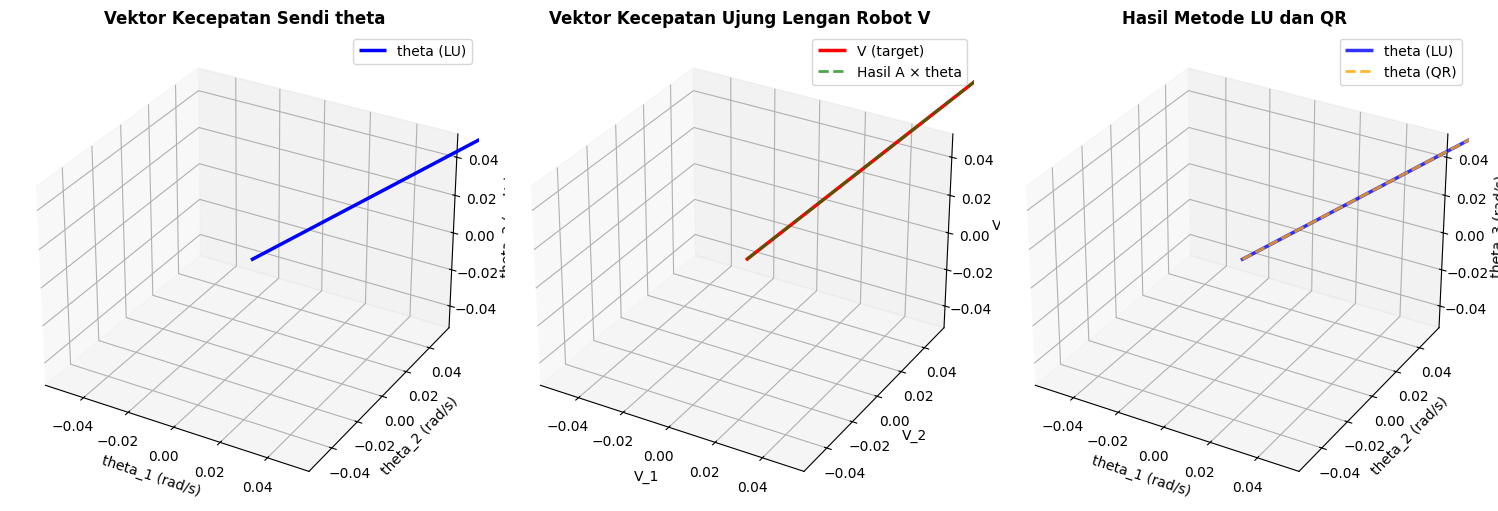

In [58]:
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
origin = [0, 0, 0]
ax1.quiver(origin[0], origin[1], origin[2],
          theta_lu[0], theta_lu[1], theta_lu[2],
          color='blue', arrow_length_ratio=0.15, linewidth=2.5, label='theta (LU)')
ax1.set_xlabel('theta_1 (rad/s)', fontsize=10)
ax1.set_ylabel('theta_2 (rad/s)', fontsize=10)
ax1.set_zlabel('theta_3 (rad/s)', fontsize=10)
ax1.set_title('Vektor Kecepatan Sendi theta', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(132, projection='3d')
ax2.quiver(origin[0], origin[1], origin[2],
          V[0], V[1], V[2],
          color='red', arrow_length_ratio=0.15, linewidth=2.5, label='V (target)')
ax2.quiver(origin[0], origin[1], origin[2],
          V_verifikasi_lu[0], V_verifikasi_lu[1], V_verifikasi_lu[2],
          color='green', arrow_length_ratio=0.15, linewidth=2,
          linestyle='--', alpha=0.7, label='Hasil A × theta')
ax2.set_xlabel('V_1', fontsize=10)
ax2.set_ylabel('V_2', fontsize=10)
ax2.set_zlabel('V_3', fontsize=10)
ax2.set_title('Vektor Kecepatan Ujung Lengan Robot V', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(133, projection='3d')
ax3.quiver(origin[0], origin[1], origin[2],
          theta_lu[0], theta_lu[1], theta_lu[2],
          color='blue', arrow_length_ratio=0.15, linewidth=2.5,
          label='theta (LU)', alpha=0.8)
ax3.quiver(origin[0], origin[1], origin[2],
          theta_qr[0], theta_qr[1], theta_qr[2],
          color='orange', arrow_length_ratio=0.15, linewidth=2,
          linestyle='--', label='theta (QR)', alpha=0.8)
ax3.set_xlabel('theta_1 (rad/s)', fontsize=10)
ax3.set_ylabel('theta_2 (rad/s)', fontsize=10)
ax3.set_zlabel('theta_3 (rad/s)', fontsize=10)
ax3.set_title('Hasil Metode LU dan QR', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()